
## Question 6 - Spurious Regression: Log S&P 500 and US Per Capita Mozzarella Consumption

**Data sources:**
- S&P 500: Annual average index levels, 1970–2023
- Mozzarella: USDA ERS, consommation per capita (lb/an), 1970–2023

'Sources: 
- S&P 500: Monthly levels from Robert Shiller’s dataset (Yale / Shiller data; ie_data.xls, monthly S&P 500 data from 1871). Calendar-year annual averages were computed by aggregating those monthly values. Aggregation assisted by Claude (AI).
- USDA, Economic Research Service calculations using USDA, National Agricultural Statistics Service; USDA, Farm Service Agency; USDA, Foreign Agricultural Service; and U.S. Department of Commerce, Bureau of the Census. 




**Outline:**
1. Load and visualize the two series
2. Test for unit roots (ADF tests)
3. Run the spurious regression
4. Analyze residuals: time plot, ACF, ADF
5. Conclusion

---
## 0. Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
# ADF: we compute test statistics from the ADF regression by hand; MacKinnon critical values
# and p-values are the same objects used inside statsmodels.tsa.stattools.adfuller.
from statsmodels.tsa.stattools import mackinnoncrit, mackinnonp
from statsmodels.tsa.tsatools import add_trend, lagmat

plt.rcParams.update({
    'figure.facecolor': '#fafaf8',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size': 11,
})

BLUE  = '#1d4e89'
GOLD  = '#c8860a'
RED   = '#c0392b'
GREEN = '#1a7a4a'
GRAY  = '#555555'


def ols_frml(Y, X):
    """OLS via (X'X)^{-1} X'Y. Y: (n,), X: (n, k). Returns a simple result namespace."""
    Y = np.asarray(Y, float).ravel()
    X = np.asarray(X, float)
    n, k = X.shape
    XtX = X.T @ X
    XtY = X.T @ Y
    beta = np.linalg.solve(XtX, XtY)
    resid = Y - X @ beta
    ssr = float(resid @ resid)
    tss = float((Y - Y.mean()) @ (Y - Y.mean()))
    rsq = 1.0 - ssr / tss if tss > 0 else 0.0
    df_resid = n - k
    s2 = ssr / df_resid
    cov = s2 * np.linalg.inv(XtX)
    se = np.sqrt(np.maximum(np.diag(cov), 0))
    tvals = beta / se
    pvals = 2 * stats.t.sf(np.abs(tvals), df=df_resid)
    rsq_adj = 1.0 - (1 - rsq) * (n - 1) / df_resid if df_resid > 0 else np.nan
    llf = -0.5 * n * (np.log(2 * np.pi) + np.log(ssr / n) + 1)
    aic = -2 * llf + 2 * k
    bic = -2 * llf + np.log(n) * k
    df_model = k - 1
    ess = tss - ssr
    fvalue = (ess / df_model) / (ssr / df_resid) if df_model > 0 and df_resid > 0 else np.nan
    f_pvalue = 1 - stats.f.cdf(fvalue, df_model, df_resid) if np.isfinite(fvalue) else np.nan

    class _Fit:
        pass

    out = _Fit()
    out.params = beta
    out.bse = se
    out.tvalues = tvals
    out.pvalues = pvals
    out.resid = resid
    out.rsquared = rsq
    out.rsquared_adj = rsq_adj
    out.aic = aic
    out.bic = bic
    out.llf = llf
    out.nobs = n
    out.k_params = k
    out.df_resid = df_resid
    out.ssr = ssr
    out.fvalue = fvalue
    out.f_pvalue = f_pvalue
    return out


def print_ols_summary(fit, endog_name='y', exog_names=None, title='OLS Regression Results (manual)'):
    if exog_names is None:
        exog_names = [f'x{i}' for i in range(len(fit.params))]
    print(' ' * 28 + title)
    print('=' * 78)
    print(f'Dep. Variable: {endog_name:>24}   R-squared:              {fit.rsquared:>10.3f}')
    print(f'Model: manual OLS                      Adj. R-squared:         {fit.rsquared_adj:>10.3f}')
    print(f'Method: Least Squares                  F-statistic:            {fit.fvalue:>10.1f}')
    print(f'Date: (local)                          Prob (F-statistic):     {fit.f_pvalue:>10.3g}')
    print(f'No. Observations:                 {fit.nobs:>5.0f}   AIC:                    {fit.aic:>10.2f}')
    print(f'Df Residuals:                     {fit.df_resid:>5.0f}   BIC:                    {fit.bic:>10.2f}')
    print(f'Df Model:                         {fit.k_params - 1:>5.0f}')
    print('-' * 78)
    print(f'{"":>15} {"coef":>10} {"std err":>10} {"t":>10} {"P>|t|":>10}')
    print('-' * 78)
    for i, name in enumerate(exog_names):
        print(f'{name:>15} {fit.params[i]:10.4f} {fit.bse[i]:10.3f} {fit.tvalues[i]:10.3f} {fit.pvalues[i]:10.3f}')
    print('=' * 78)


def durbin_watson_stat(resid):
    e = np.asarray(resid, float).ravel()
    de = np.diff(e)
    return float((de @ de) / (e @ e))


def sample_acf(series, nlags):
    x = np.asarray(series, float).ravel()
    x = x - x.mean()
    n = len(x)
    denom = float(x @ x)
    out = np.empty(nlags + 1)
    out[0] = 1.0
    for lag in range(1, nlags + 1):
        out[lag] = float((x[lag:] @ x[:-lag]) / denom)
    return out


def adfuller_manual(x, autolag='AIC', regression='c'):
    """Augmented Dickey–Fuller: same regression layout as statsmodels.adfuller; statistic = t on y_{t-1}."""
    x = np.asarray(x, float).ravel()
    xdiff = np.diff(x)
    ntrend = len(regression) if regression != 'n' else 0
    n_full = len(x)
    maxlag = int(np.ceil(12.0 * np.power(n_full / 100.0, 1 / 4.0)))
    maxlag = min(n_full // 2 - ntrend - 1, maxlag)

    xdall = lagmat(xdiff[:, None], maxlag, trim='both', original='in')
    nobs = xdall.shape[0]
    xdall[:, 0] = x[-nobs - 1: -1]
    xdshort = xdiff[-nobs:]
    fullRHS = add_trend(xdall, regression, prepend=True)
    startlag = fullRHS.shape[1] - xdall.shape[1] + 1

    icbest = np.inf
    bestlag_col = startlag
    method = autolag.upper()
    for lag in range(startlag, startlag + maxlag + 1):
        Z = fullRHS[:, :lag]
        fit = ols_frml(xdshort, Z)
        ic = fit.aic if method == 'AIC' else fit.bic
        if ic < icbest:
            icbest, bestlag_col = ic, lag

    usedlag = bestlag_col - startlag
    xdall = lagmat(xdiff[:, None], usedlag, trim='both', original='in')
    nobs = xdall.shape[0]
    xdall[:, 0] = x[-nobs - 1: -1]
    xdshort = xdiff[-nobs:]
    Z = add_trend(xdall[:, : usedlag + 1], regression)
    fit = ols_frml(xdshort, Z)

    adfstat = float(fit.tvalues[0])
    pvalue = float(mackinnonp(adfstat, regression=regression, N=1))
    crit_arr = mackinnoncrit(N=1, regression=regression, nobs=nobs)
    critvalues = {'1%': crit_arr[0], '5%': crit_arr[1], '10%': crit_arr[2]}
    return adfstat, pvalue, usedlag, nobs, critvalues, icbest

---
## 1. Data

We use two series that are **economically unrelated**:
- **log S&P 500**: a financial price index — the textbook example of an $I(1)$ process (random walk with drift).
- **log US per capita mozzarella consumption**: a demographic/food trend series — strongly trending and highly persistent; formal unit-root classification can differ from the S&P (see ADF output below).


There is no plausible causal mechanism linking mozzarella consumption to equity valuations. This makes the pair an ideal illustration of spurious regression.


In [ ]:
years = np.arange(1970, 2024)

# USDA ERS — consommation per capita de mozzarella (lb/an), 1970–2023
cheese_vals = [
    1.19, 1.38, 1.57, 1.76, 1.86, 2.11, 2.31, 2.46, 2.68, 2.80,
    3.01, 2.96, 3.24, 3.66, 4.02, 4.60, 5.17, 5.60, 5.99, 6.40,
    6.88, 7.15, 7.63, 7.42, 7.76, 7.9, 8.2, 8.2, 8.3, 8.7,
    9.1, 9.3, 9.4, 9.5, 9.7, 9.9, 10.1, 10.7, 10.1, 10.1,
    10.6, 10.8, 10.7, 10.7, 11.1, 11.2, 11.7, 11.6, 12.1, 12.4,
    12.2, 12.3, 12.6, 12.4,
]

# S&P 500 annual average levels
sp500_vals = [
      84,   98,  111,  107,   82,   90,  102,   99,   97,  104,
     119,  128,  120,  160,  160,  187,  237,  286,  266,  322,
     335,  376,  415,  451,  460,  541,  671,  873, 1085, 1327,
    1427, 1194,  994,  965, 1131, 1207, 1311, 1477, 1220,  950,
    1139, 1268, 1379, 1643, 1931, 2061, 2094, 2449, 2746, 2913,
    3217, 4274, 4098, 4210
]

df = pd.DataFrame({'year': years, 'cheese': cheese_vals, 'sp500': sp500_vals})
df['log_sp500']  = np.log(df['sp500'])
df['log_cheese'] = np.log(df['cheese'])

print(df[['year','cheese','sp500','log_cheese','log_sp500']].to_string(index=False))

 year  cheese  sp500  log_cheese  log_sp500
 1970    1.19     84    0.173953   4.430817
 1971    1.38     98    0.322083   4.584967
 1972    1.57    111    0.451076   4.709530
 1973    1.76    107    0.565314   4.672829
 1974    1.86     82    0.620576   4.406719
 1975    2.11     90    0.746688   4.499810
 1976    2.31    102    0.837248   4.624973
 1977    2.46     99    0.900161   4.595120
 1978    2.68     97    0.985817   4.574711
 1979    2.80    104    1.029619   4.644391
 1980    3.01    119    1.101940   4.779123
 1981    2.96    128    1.085189   4.852030
 1982    3.24    120    1.175573   4.787492
 1983    3.66    160    1.297463   5.075174
 1984    4.02    160    1.391282   5.075174
 1985    4.60    187    1.526056   5.231109
 1986    5.17    237    1.642873   5.468060
 1987    5.60    286    1.722767   5.655992
 1988    5.99    266    1.790091   5.583496
 1989    6.40    322    1.856298   5.774552
 1990    6.88    335    1.928619   5.814131
 1991    7.15    376    1.967112

### 1.1 Time series plot

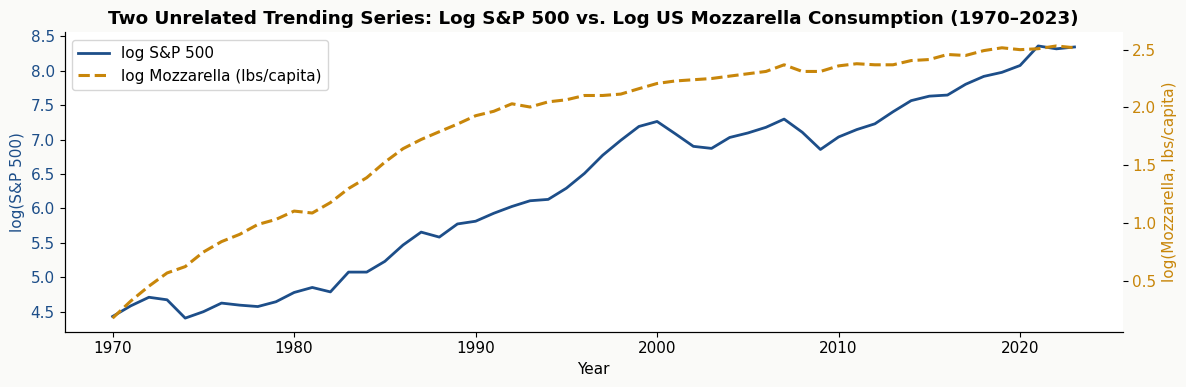

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(df.year, df.log_sp500,  color=BLUE, lw=2,   label='log S&P 500')
ax2.plot(df.year, df.log_cheese, color=GOLD, lw=2.2, label='log Mozzarella (lbs/capita)', ls='--')

ax1.set_ylabel('log(S&P 500)',             color=BLUE, fontsize=11)
ax2.set_ylabel('log(Mozzarella, lbs/capita)', color=GOLD, fontsize=11)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=GOLD)
ax1.set_xlabel('Year')
ax1.set_title('Two Unrelated Trending Series: Log S&P 500 vs. Log US Mozzarella Consumption (1970–2023)',
              fontweight='bold')

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')
plt.tight_layout()
plt.show()

**Observation:** Both series display a persistent upward trend. This visual co-movement is purely the result of shared trending behavior — not any underlying economic relationship. Any two series that both happen to trend upward over 50 years will look like this.

---
## 2. Unit Root Tests (ADF)

We apply the Augmented Dickey-Fuller (ADF) test to each series in **levels** and **first differences**.

- $H_0$: series has a unit root (is non-stationary, $I(1)$)
- $H_1$: series is stationary ($I(0)$)

We fail to reject $H_0$ at the 10% level if $p > 0.10$.

In [12]:
y = df['log_sp500'].values
x = df['log_cheese'].values


def adf_summary(name, series):
    adfstat, pvalue, usedlag, _nobs, _crit, _ic = adfuller_manual(
        series, autolag='AIC', regression='c'
    )
    verdict = 'I(1): fail to reject H0' if pvalue > 0.10 else 'I(0): reject H0'
    print(
        f"  {name:<30}  ADF = {adfstat:7.3f}   p = {pvalue:.4f}   lags = {usedlag}   => {verdict}"
    )

print("=" * 80)
print("LEVELS")
print("=" * 80)
adf_summary('log(S&P 500)', y)
adf_summary('log(Mozzarella consumption)', x)

print()
print("=" * 80)
print("FIRST DIFFERENCES")
print("=" * 80)
adf_summary('Δ log(S&P 500)', np.diff(y))
adf_summary('Δ log(Mozzarella consumption)', np.diff(x))

LEVELS
  log(S&P 500)                    ADF =  -1.251   p = 0.6514   lags = 9   => I(1): fail to reject H0
  log(Mozzarella consumption)     ADF =  -7.926   p = 0.0000   lags = 0   => I(0): reject H0

FIRST DIFFERENCES
  Δ log(S&P 500)                  ADF =  -2.793   p = 0.0593   lags = 8   => I(0): reject H0
  Δ log(Mozzarella consumption)   ADF =  -2.337   p = 0.1602   lags = 2   => I(1): fail to reject H0


**Conclusion (matches the printed tests):**
- **$\log(\text{S\&P 500})$ (levels):** fail to reject a unit root ($p > 0.10$) — treated as **$I(1)$** here.
- **$\log(\text{mozzarella})$ (levels):** **reject** a unit root ($p < 0.10$) — ADF labels this **$I(0)$** in this sample (trending series can still give ambiguous integration-class results across tests/specs).
- **First differences:** $\Delta\log(\text{S\&P})$ is borderline stationary at 10%; $\Delta\log(\text{mozzarella})$ still fails to reject a unit root at 10% in this run.

The **textbook** spurious-regression story assumes two independent **$I(1)$** series in levels. With mozzarella, that assumption is not literally satisfied, yet the level regression below still shows the usual **high $R^2$ + very low Durbin–Watson + non-$I(0)$ residuals** warning pattern.

---
## 3. The Spurious Regression

We run:
$$\log(\text{S\&P}_{t}) = \alpha + \beta \cdot \log(\text{Mozzarella}_{t}) + \hat{u}_t$$

With $\log(\text{S\&P})$ non-stationary in levels (per ADF) and mozzarella strongly trending — and **no economic link** between the two — standard level-OLS inference is unreliable (Granger & Newbold, 1974):
- $\hat{u}_t \sim I(1)$: the residuals are non-stationary, violating the OLS assumption $u_t \sim I(0)$
- $R^2 \to$ random limit as $T \to \infty$ (does **not** converge to 0)
- $t_{\hat{\beta}} \to \infty$ as $T \to \infty$ (diverges, so $H_0: \beta=0$ is nearly always rejected)
- $\hat{\beta}$ is **inconsistent**: it does not converge to the true value of 0

In [13]:
# Y = log S&P 500, X = [1, log mozzarella]  —  β̂ = (X'X)^{-1} X'Y
n = len(y)
Xc = np.column_stack([np.ones(n), x])
model = ols_frml(y, Xc)
resid = model.resid
dw = durbin_watson_stat(resid)

print_ols_summary(model, endog_name='log_sp500', exog_names=['const', 'log_mozzarella'])
print(f"\nDurbin-Watson statistic = {dw:.4f}")
print("(DW ≈ 2 expected under no autocorrelation; DW ≪ 2 signals I(1) residuals)")

                            OLS Regression Results (manual)
Dep. Variable:                log_sp500   R-squared:                   0.869
Model: manual OLS                      Adj. R-squared:              0.867
Method: Least Squares                  F-statistic:                 346.1
Date: (local)                          Prob (F-statistic):       1.11e-16
No. Observations:                    54   AIC:                         70.31
Df Residuals:                        52   BIC:                         74.29
Df Model:                             1
------------------------------------------------------------------------------
                      coef    std err          t      P>|t|
------------------------------------------------------------------------------
          const     3.1792      0.180     17.707      0.000
 log_mozzarella     1.7124      0.092     18.603      0.000

Durbin-Watson statistic = 0.0910
(DW ≈ 2 expected under no autocorrelation; DW ≪ 2 signals I(1) residuals)


**Key numbers to report:**

| Statistic | Value | Interpretation |
|---|---|---|
| $\hat{\beta}$ | $\approx 1.71$ | "Ceteris Paribus, 1% more mozzarella → ~1.7% higher S&P" — economically nonsensical |
| $t$-statistic | $\approx 18.6$ | Highly "significant" in-sample — not trustworthy when residuals are persistent |
| $R^2$ | $\approx 0.87$ | Very high in-sample $R^2$ despite no causal link |
| **Durbin-Watson** | $\approx 0.09 \ll 2$ | **Classic symptom**: high $R^2$ + very low DW $\Rightarrow$ misleading OLS |

> *"High $R^2$, t-values, F-value, but low D/W"* — the textbook warning sign (Lecture Week 2).

---
## 4. Residual Analysis

The definitive test for spurious regression is the behavior of the residuals $\hat{u}_t$.

### 4.1 ADF test on residuals

In [14]:
adf_u, p_u, _lag_u, _n_u, crit_u, _ic_u = adfuller_manual(resid, autolag='AIC', regression='c')
print("ADF test on regression residuals:")
print(f"  ADF statistic = {adf_u:.4f}")
print(f"  p-value       = {p_u:.4f}")
print(
    f"  Critical values: 1% = {crit_u['1%']:.3f},  5% = {crit_u['5%']:.3f},  10% = {crit_u['10%']:.3f}"
)
print()
if p_u > 0.10:
    print("=> FAIL TO REJECT H0: residuals have a unit root => I(1) residuals => SPURIOUS REGRESSION")
else:
    print("=> REJECT H0: residuals are stationary => potential cointegration")

ADF test on regression residuals:
  ADF statistic = -0.8978
  p-value       = 0.7887
  Critical values: 1% = -3.581,  5% = -2.927,  10% = -2.602

=> FAIL TO REJECT H0: residuals have a unit root => I(1) residuals => SPURIOUS REGRESSION


### 4.2 Residual time plot and ACF

/var/folders/r4/f5g28s4d4nlc0v8zxdw6c9b40000gn/T/ipykernel_12916/362607423.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


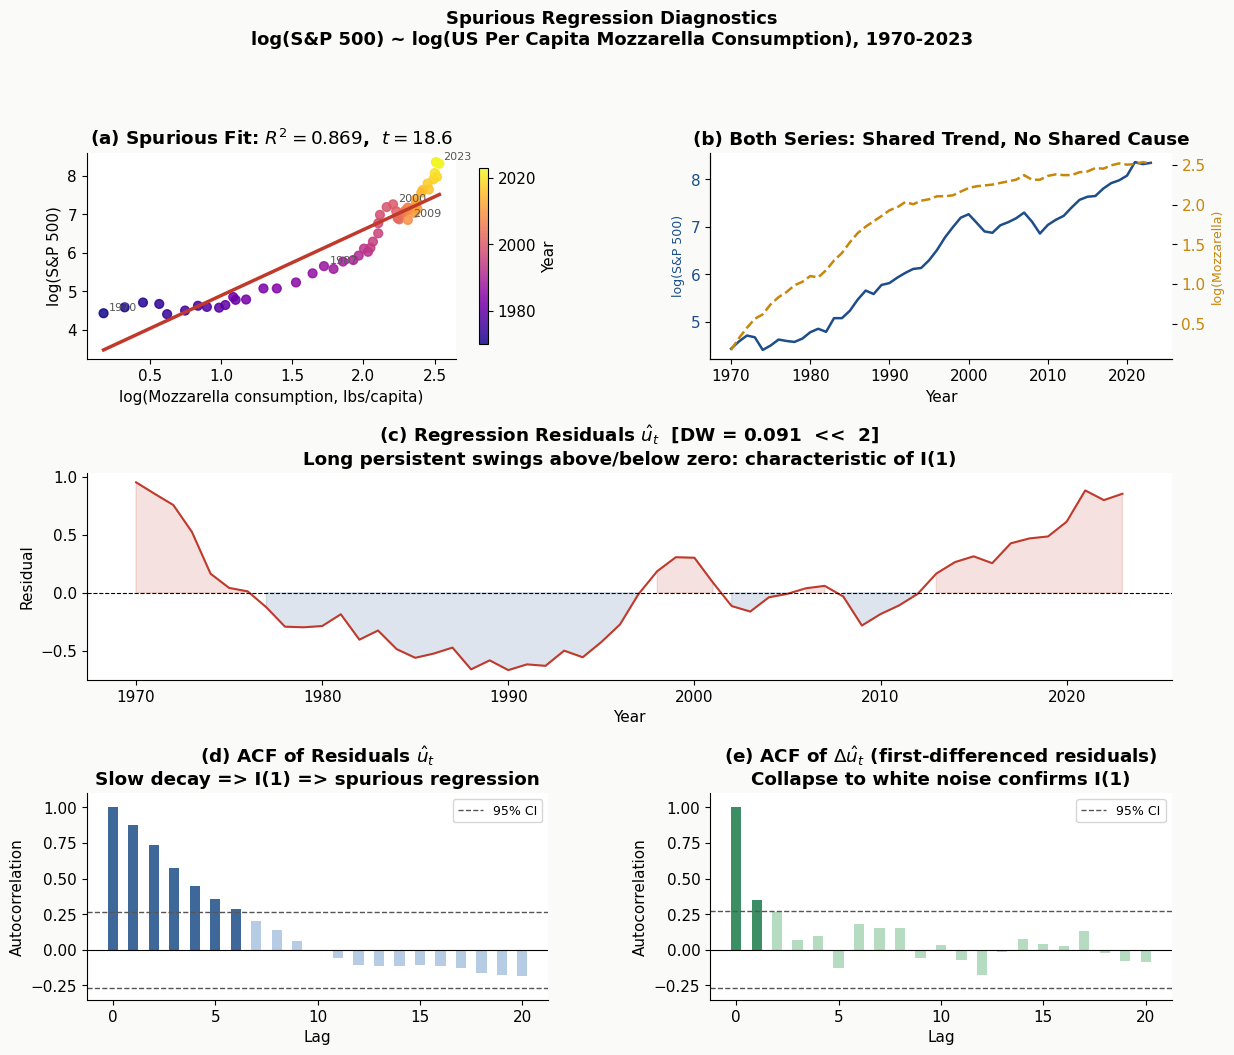

In [15]:
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── Scatter with fit ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sc  = ax1.scatter(x, y, c=years, cmap='plasma', s=40, alpha=0.85, zorder=3)
plt.colorbar(sc, ax=ax1, label='Year', shrink=0.85)
xfit = np.linspace(x.min(), x.max(), 200)
yfit = model.params[0] + model.params[1] * xfit
ax1.plot(xfit, yfit, color=RED, lw=2.5, zorder=4)
r2, t_beta = model.rsquared, float(model.tvalues[1])
ax1.set_title(f'(a) Spurious Fit: $R^2={r2:.3f}$,  $t={t_beta:.1f}$', fontweight='bold')
ax1.set_xlabel('log(Mozzarella consumption, lbs/capita)')
ax1.set_ylabel('log(S&P 500)')
# annotate a few years
for yr, lbl in [(1970,'1970'),(1987,'1987'),(2000,'2000'),(2009,'2009'),(2023,'2023')]:
    idx = np.where(years == yr)[0][0]
    ax1.annotate(lbl, (x[idx], y[idx]), fontsize=8, xytext=(4,2),
                 textcoords='offset points', color=GRAY)

# ── Both series over time ─────────────────────────────────────────────────────
ax2  = fig.add_subplot(gs[0, 1])
ax2b = ax2.twinx()
ax2.plot(years, y, color=BLUE, lw=1.8, label='log S&P 500')
ax2b.plot(years, x, color=GOLD, lw=1.8, ls='--', label='log Mozzarella')
ax2.set_ylabel('log(S&P 500)',  color=BLUE,  fontsize=9)
ax2b.set_ylabel('log(Mozzarella)',  color=GOLD,  fontsize=9)
ax2.tick_params(axis='y', labelcolor=BLUE)
ax2b.tick_params(axis='y', labelcolor=GOLD)
ax2.set_title('(b) Both Series: Shared Trend, No Shared Cause', fontweight='bold')
ax2.set_xlabel('Year')

# ── Residuals over time ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(years, resid, color=RED, lw=1.5)
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.fill_between(years, resid, 0, where=resid>=0, alpha=0.15, color=RED)
ax3.fill_between(years, resid, 0, where=resid<0,  alpha=0.15, color=BLUE)
ax3.set_title(f'(c) Regression Residuals $\\hat{{u}}_t$  [DW = {dw:.3f}  <<  2]\n'
               'Long persistent swings above/below zero: characteristic of I(1)',
              fontweight='bold')
ax3.set_ylabel('Residual'); ax3.set_xlabel('Year')

# ── ACF of residuals ──────────────────────────────────────────────────────────
nlags   = 20
acf_u   = sample_acf(resid, nlags)
acf_du  = sample_acf(np.diff(resid), nlags)
ci      = 1.96 / np.sqrt(len(resid))
lag_x   = np.arange(nlags + 1)

ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(lag_x, acf_u, color=[BLUE if abs(v) > ci else '#aac4e0' for v in acf_u],
        width=0.5, alpha=0.85)
ax4.axhline( ci, color=GRAY, lw=1, ls='--', label='95% CI')
ax4.axhline(-ci, color=GRAY, lw=1, ls='--')
ax4.axhline(0, color='black', lw=0.8)
ax4.set_title('(d) ACF of Residuals $\\hat{u}_t$\nSlow decay => I(1) => spurious regression',
              fontweight='bold')
ax4.set_xlabel('Lag'); ax4.set_ylabel('Autocorrelation')
ax4.set_ylim(-0.35, 1.1)
ax4.legend(fontsize=9)

ax5 = fig.add_subplot(gs[2, 1])
ci_d = 1.96 / np.sqrt(len(resid) - 1)
ax5.bar(lag_x, acf_du, color=[GREEN if abs(v) > ci_d else '#a8d5b5' for v in acf_du],
        width=0.5, alpha=0.85)
ax5.axhline( ci_d, color=GRAY, lw=1, ls='--', label='95% CI')
ax5.axhline(-ci_d, color=GRAY, lw=1, ls='--')
ax5.axhline(0, color='black', lw=0.8)
ax5.set_title('(e) ACF of $\\Delta\\hat{u}_t$ (first-differenced residuals)\nCollapse to white noise confirms I(1)',
              fontweight='bold')
ax5.set_xlabel('Lag'); ax5.set_ylabel('Autocorrelation')
ax5.set_ylim(-0.35, 1.1)
ax5.legend(fontsize=9)

fig.suptitle('Spurious Regression Diagnostics\nlog(S&P 500) ~ log(US Per Capita Mozzarella Consumption), 1970-2023',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Interpretation of autocorrelation pattern

The ACF of the residuals is the decisive diagnostic:

| Feature | What we see | What it means |
|---|---|---|
| **ACF at lag 1** | Close to 1.0 | Residuals are extremely persistent |
| **ACF decay** | Hyperbolic / very slow | Characteristic of an $I(1)$ process |
| **ACF after differencing** | Drops to ~0 immediately | Confirms $\hat{u}_t \sim I(1)$ |
| **Durbin-Watson** | $\approx 0.09 \ll 2$ | Textbook symptom of strongly autocorrelated / persistent residuals |
| **ADF on $\hat{u}_t$** | $p \approx 0.79 > 0.10$ | Cannot reject unit root in residuals (see printed test) |

This pattern — slow ACF decay, DW far below 2, and ADF failure to reject on $\hat{u}_t$ — matches **misleading level regressions between trending series** (the classic spurious-regression warning).

Contrast with a **valid** regression: residuals would be $I(0)$, ACF would cut off after a few lags, and DW $\approx 2$.

---
## 5. Conclusion

This regression is **spurious** for the following reasons:

1. **Integration properties (see ADF output):** $\log(\text{S\&P 500})$ fails to reject a unit root in levels ($I(1)$ in this table). $\log(\text{mozzarella})$ **rejects** a unit root in levels here ($I(0)$ in that test), so the clean “two independent $I(1)$ series” textbook setup is not literally satisfied — yet the regression still looks “too good to be true.”

2. **No economic relationship exists**: mozzarella consumption is driven by demographic trends and dietary patterns; the S&P 500 is driven by corporate earnings, monetary policy, and risk appetite. There is no plausible causal channel.

3. **Residuals are $I(1)$**: the ADF test on $\hat{u}_t$ fails to reject the unit root (see output above). This violates the fundamental OLS assumption that $u_t \sim I(0)$.

4. **Classic symptom**: very high $R^2$ and $t$-statistics together with a Durbin–Watson statistic far below 2 — the "high $R^2$, high $t$, low DW" pattern flagged in lecture as the tell-tale sign of spurious regression.

5. **Classical OLS inference is not valid here:** with persistent errors (low DW, unit-root-like residuals), $t$- and $F$-tests are not reliable; in the textbook $I(1)$–$I(1)$ spurious-regression limit, $\hat{\beta}$ is inconsistent and test statistics diverge.

### Fix: first-difference regression

Regressing $\Delta\log(\text{S\&P}_t)$ on $\Delta\log(\text{Mozzarella}_t)$ produces (see output):
- $R^2 \approx 0.03$ (small)
- Slope insignificant at 5% ($t \approx 1.34$, $p \approx 0.19$)
- DW $\approx 1.5$ — closer to 2 than the level regression, but not a perfect “white-noise errors” benchmark

...so the strong level “link” largely disappears in first differences, as expected when the level fit is spurious.

In [16]:
# Fix: regress first differences (manual OLS)
dy = np.diff(y)
dx = np.diff(x)
nd = len(dy)
Xd = np.column_stack([np.ones(nd), dx])
model_diff = ols_frml(dy, Xd)
dw_diff = durbin_watson_stat(model_diff.resid)

print("FIRST-DIFFERENCE REGRESSION: Delta log(SP500) ~ Delta log(Mozzarella)")
print_ols_summary(model_diff, endog_name='d_log_sp500', exog_names=['const', 'd_log_mozzarella'])
print(f"\nDurbin-Watson = {dw_diff:.4f}")
print("\nSmall R^2, insignificant slope at 5%, DW closer to 2 => level 'relationship' largely gone.")

FIRST-DIFFERENCE REGRESSION: Delta log(SP500) ~ Delta log(Mozzarella)
                            OLS Regression Results (manual)
Dep. Variable:              d_log_sp500   R-squared:                   0.034
Model: manual OLS                      Adj. R-squared:              0.015
Method: Least Squares                  F-statistic:                   1.8
Date: (local)                          Prob (F-statistic):          0.186
No. Observations:                    53   AIC:                        -66.44
Df Residuals:                        51   BIC:                        -62.49
Df Model:                             1
------------------------------------------------------------------------------
                      coef    std err          t      P>|t|
------------------------------------------------------------------------------
          const     0.0513      0.024      2.115      0.039
d_log_mozzarella     0.5107      0.381      1.340      0.186

Durbin-Watson = 1.5325

Small R^2, in